# SI — Novelty granularity

Produces `figures/fig_SI4.pdf`: the intrinsic-time law `D(t)` and the branching
relation `D_w(D)` at three novelty resolutions — single elements, pairs, full
combinations — for both datasets.

Requires the granularity cache built by `si_build_granularity.ipynb`.


In [1]:
# Repository bootstrap.
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "lib").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT / "lib") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "lib"))

OUTPUT_DIR = REPO_ROOT / "outputs"               # derived data, auto-generated
FIGURE_DIR = REPO_ROOT / "figures"               # manuscript figures, versioned
GRANULARITY_DIR = OUTPUT_DIR / "granularity"     # built by si_build_granularity

# Papers without keywords cannot produce a combination novelty and are excluded
# from the event process. This is the convention of the revised manuscript.
filter_empty_keywords = True


## Imports and style


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from plot_style import apply_si_style, PAPER_COLORS, SI_DATA_LW

apply_si_style()
colors = list(PAPER_COLORS)

pd.set_option("display.max_columns", 60)


## Load the three resolutions

The cache carries the same event sequence counted three ways: `D_single`
(distinct elements), `D_pair` (distinct pairs) and `D_combo` (distinct full
combinations, the definition used in the main text).


In [3]:
from analysis_utils import load_granularity_datasets

datasets = load_granularity_datasets(
    GRANULARITY_DIR,
    filter_empty_keywords=filter_empty_keywords,
)

display(pd.DataFrame([{
    "dataset": name,
    "events": len(data["events"]),
    "final_t": int(data["events"]["t"].iloc[-1]),
    "final_D_single": int(data["events"]["D_single"].iloc[-1]),
    "final_D_pair": int(data["events"]["D_pair"].iloc[-1]),
    "final_D_combo": int(data["events"]["D_combo"].iloc[-1]),
    "final_Dw_first": int(data["events"]["Dw_first"].iloc[-1]),
    "final_Dw_all": int(data["events"]["Dw_all"].iloc[-1]),
} for name, data in datasets.items()]))


,dataset,events,final_t,final_D_single,final_D_pair,final_D_combo,final_Dw_first,final_Dw_all
0,patents,1431653,1431653,71782,2537902,706996,893828,1989732
1,papers,5193236,5193236,35026,1860029,1890430,1333013,3045970


## The figure

2×2 grid: rows are datasets, columns are `D(t)` and `D_w(D)`, both on log-log
axes with the three resolutions overlaid. The effective exponent of each curve
is fitted over the whole observation window and reported in the legend.


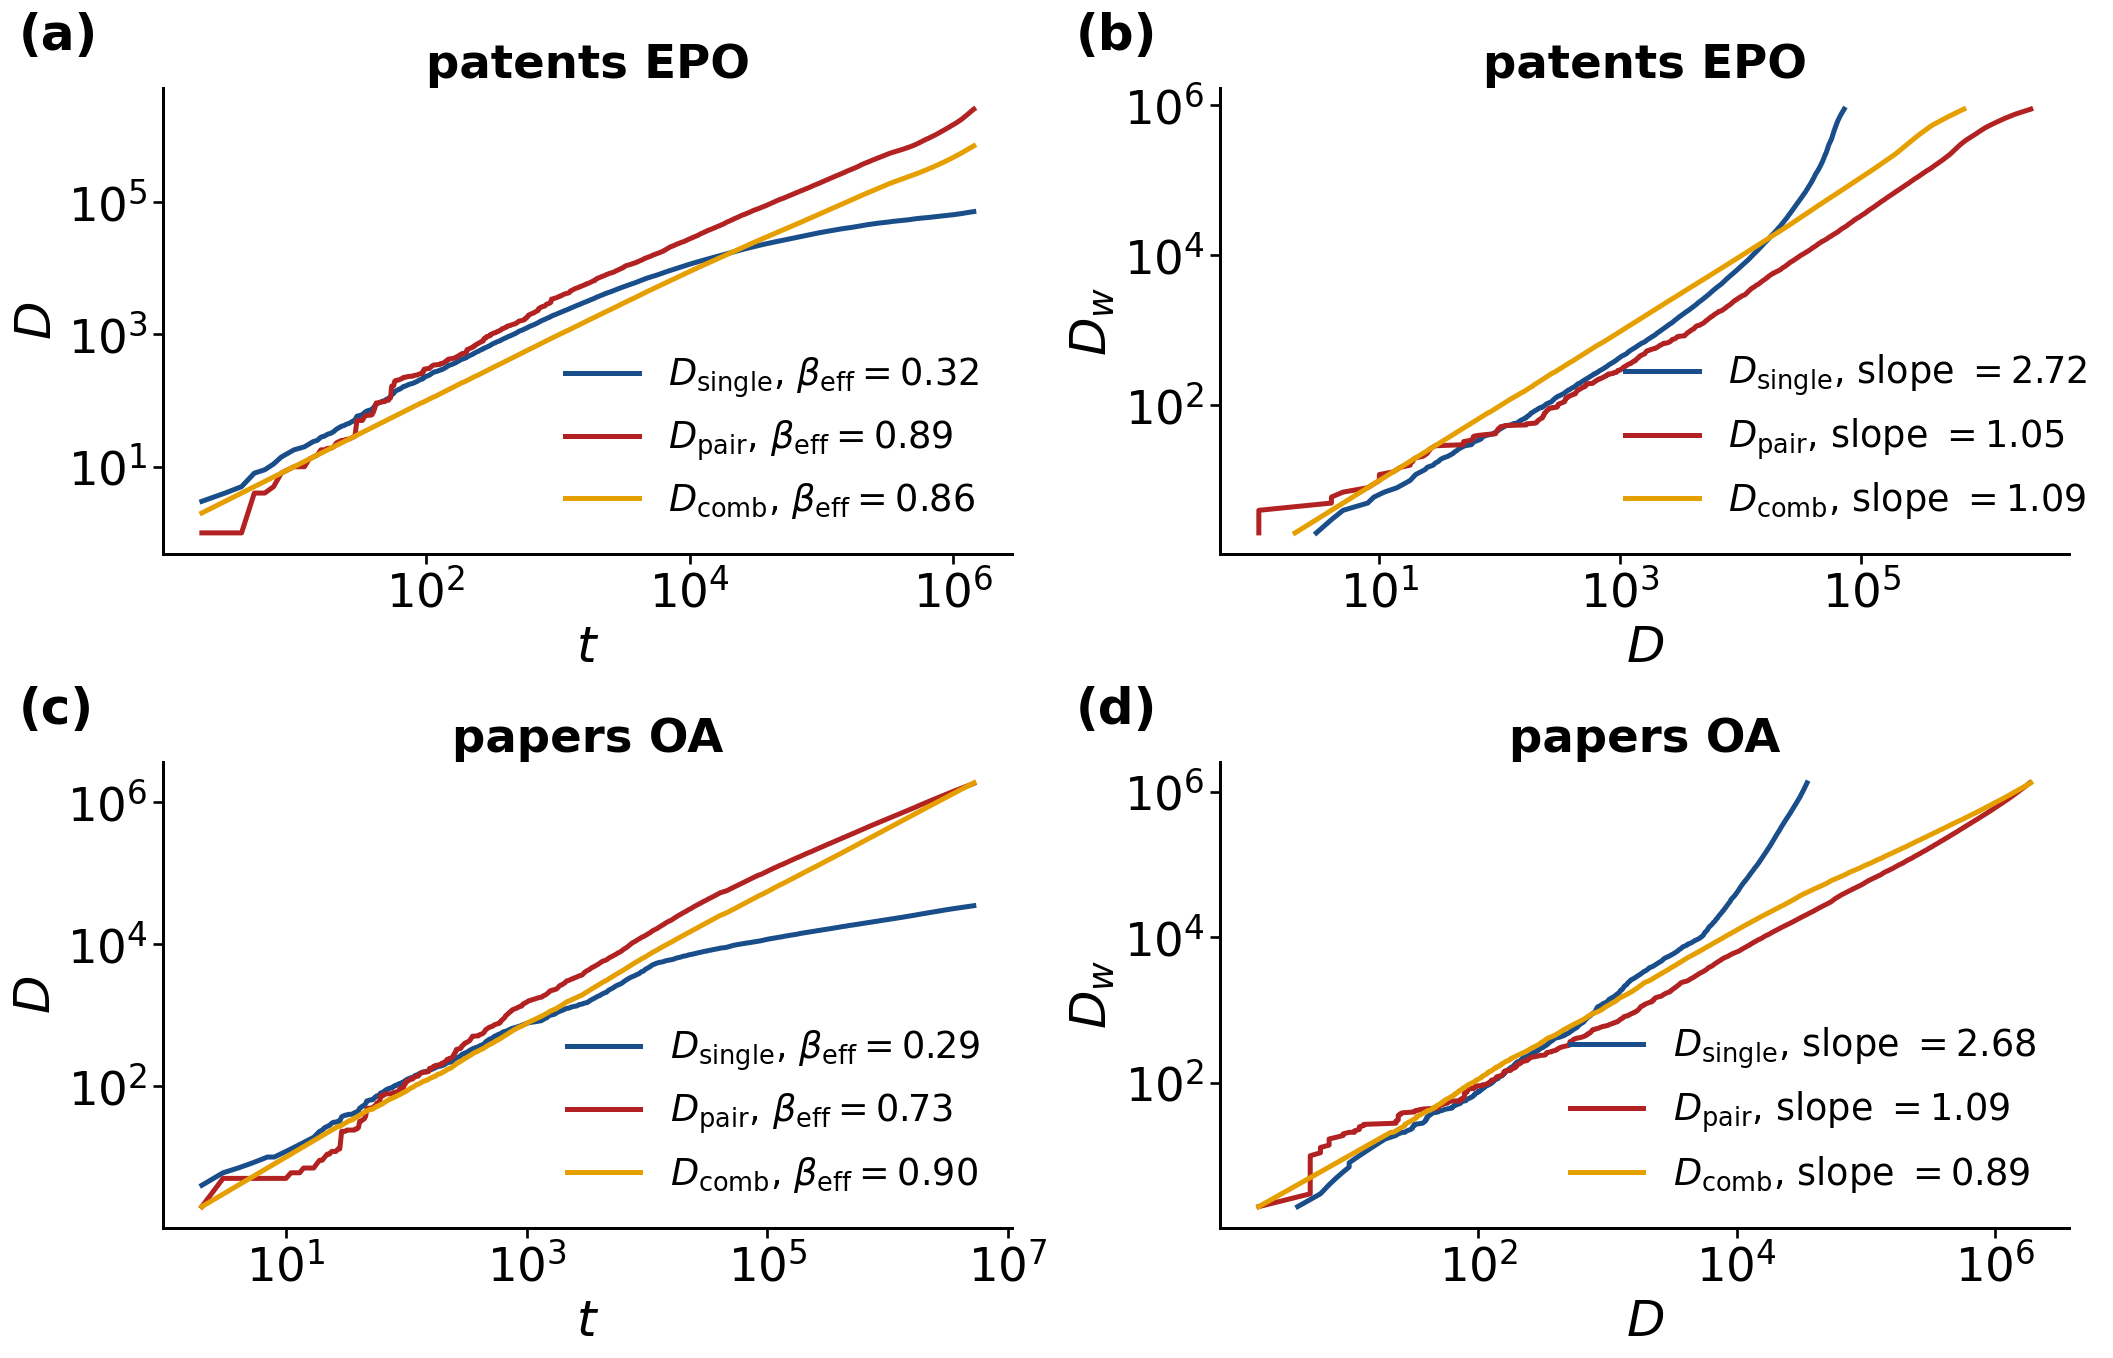

figure -> figures/fig_SI4.pdf
('papers', 'D_combo', 'beta_D_t') 0.899
('papers', 'D_combo', 'slope_Dw_D') 0.886
('papers', 'D_pair', 'beta_D_t') 0.731
('papers', 'D_pair', 'slope_Dw_D') 1.086
('papers', 'D_single', 'beta_D_t') 0.291
('papers', 'D_single', 'slope_Dw_D') 2.679
('patents', 'D_combo', 'beta_D_t') 0.862
('patents', 'D_combo', 'slope_Dw_D') 1.091
('patents', 'D_pair', 'beta_D_t') 0.892
('patents', 'D_pair', 'slope_Dw_D') 1.046
('patents', 'D_single', 'beta_D_t') 0.322
('patents', 'D_single', 'slope_Dw_D') 2.719


In [4]:
# Final SI figure for the novelty-granularity section.
# 2x2 grid: rows are datasets, columns are the intrinsic-time law D(t) and the
# branching relation D_w(D), both on log-log axes, with the three novelty
# resolutions (single elements, pairs, full combinations) overlaid.
import statsmodels.api as sm

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

GRANULARITY_SCALES = [
    ("D_single", r"$D_{\mathrm{single}}$", colors[0]),
    ("D_pair", r"$D_{\mathrm{pair}}$", colors[1]),
    ("D_combo", r"$D_{\mathrm{comb}}$", colors[2]),
]
DATASET_TITLE = {"patents": "patents EPO", "papers": "papers OA"}


def _log_subsample(n, n_points=1200):
    """Indices spread uniformly in log space, for smooth log-log curves."""
    return np.unique(np.round(np.logspace(0, np.log10(n - 1), n_points)).astype(int))


def _loglog_slope(x, y):
    """Effective power-law exponent over the full observation window."""
    mask = (x > 1) & (y > 0)
    fit = sm.OLS(np.log(y[mask]), sm.add_constant(np.log(x[mask]))).fit()
    return float(fit.params[1])


fig, axes = plt.subplots(2, 2, figsize=(17.5, 11.2), constrained_layout=True)
panel_labels = [["(a)", "(b)"], ["(c)", "(d)"]]
granularity_exponents = {}

for row_idx, name in enumerate(["patents", "papers"]):
    events = datasets[name]["events"]
    t_vals = events["t"].to_numpy(dtype=float)
    Dw_vals = events["Dw_first"].to_numpy(dtype=float)
    idx = _log_subsample(len(t_vals))

    ax = axes[row_idx, 0]
    for column, tex, color in GRANULARITY_SCALES:
        D_vals = events[column].to_numpy(dtype=float)
        beta = _loglog_slope(t_vals, D_vals)
        granularity_exponents[(name, column, "beta_D_t")] = beta
        ax.loglog(t_vals[idx], np.maximum(D_vals[idx], 1e-9), lw=SI_DATA_LW,
                  color=color, label=r"%s, $\beta_{\mathrm{eff}} = %.2f$" % (tex, beta))
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$D$")
    ax.set_title(DATASET_TITLE[name], fontsize=28, fontweight="bold")
    ax.legend(loc="lower right", frameon=False, fontsize=22)

    ax = axes[row_idx, 1]
    for column, tex, color in GRANULARITY_SCALES:
        D_vals = events[column].to_numpy(dtype=float)
        slope = _loglog_slope(D_vals, Dw_vals)
        granularity_exponents[(name, column, "slope_Dw_D")] = slope
        positive = (D_vals > 0) & (Dw_vals > 0)
        ax.loglog(D_vals[idx][positive[idx]], Dw_vals[idx][positive[idx]],
                  lw=SI_DATA_LW, color=color,
                  label=r"%s, slope $= %.2f$" % (tex, slope))
    ax.set_xlabel(r"$D$")
    ax.set_ylabel(r"$D_w$")
    ax.set_title(DATASET_TITLE[name], fontsize=28, fontweight="bold")
    # Panel (b): the steep D_single trace runs into the first legend row, so
    # that legend alone is nudged to the right.
    legend_anchor = (1.06, 0.0) if row_idx == 0 else (1.0, 0.0)
    ax.legend(loc="lower right", bbox_to_anchor=legend_anchor,
              frameon=False, fontsize=22)

for row_idx in range(2):
    for col_idx in range(2):
        axes[row_idx, col_idx].text(
            -0.17, 1.06, panel_labels[row_idx][col_idx],
            transform=axes[row_idx, col_idx].transAxes,
            va="bottom", ha="left", fontsize=30, fontweight="bold",
        )

fig.savefig(FIGURE_DIR / "fig_SI4.pdf", format="pdf", facecolor="white")
plt.show()
print("figure ->", (FIGURE_DIR / "fig_SI4.pdf").relative_to(REPO_ROOT))
for key, value in sorted(granularity_exponents.items()):
    print(key, "%.3f" % value)
